In [25]:
import numpy as np

docs = [
    'go india',
    'india india',
    'hip hip hurray',
    'jeetega bhai jeetega india jeetega',
    'bharat mata ki jai',
    'kohli kohli',
    'sachin sachin',
    'dhoni dhoni',
    'modi ji ki jai',
    'inquilab zindabad'
]

In [26]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Embedding
from keras.models import Sequential

In [27]:
tokenizer=Tokenizer()

In [28]:
tokenizer.fit_on_texts(docs)

In [29]:
len(tokenizer.word_index)

17

In [30]:
sequence=tokenizer.texts_to_sequences(docs)

In [31]:
from keras.utils import pad_sequences

In [32]:
sequence=pad_sequences(sequence, padding='post')

In [33]:
sequence

array([[ 9,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3, 10,  0,  0],
       [ 2, 11,  2,  1,  2],
       [12, 13,  4,  5,  0],
       [ 6,  6,  0,  0,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [14, 15,  4,  5,  0],
       [16, 17,  0,  0,  0]])

In [34]:
model=Sequential()

model.add(Embedding(18, output_dim=2, input_length=5))

# Explicitly build the model with a dummy input
model(np.array(sequence))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (10, 5, 2)             │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36 (144.00 B)

 Trainable params: 36 (144.00 B)

 Non-trainable params: 0 (0.00 B)

# Directly importing IMDB data from keras and applying sentiment analysis

In [35]:
from keras.datasets import imdb
from keras.layers import Dense, Flatten, SimpleRNN, Embedding, Dropout # Added Dropout
from keras.models import Sequential
from keras.utils import plot_model
import matplotlib.pyplot as plt

In [36]:
from keras.datasets import imdb
from keras.layers import Dense, Flatten, SimpleRNN, Embedding, Dropout # Added Dropout
from keras.models import Sequential
from keras.utils import plot_model
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test)=imdb.load_data()

In [37]:
# Calculate the actual vocabulary size and maximum sequence length
vocab_size = 0
for x in X_train:
    vocab_size = max(vocab_size, max(x) if len(x) > 0 else 0)
for x in X_test:
    vocab_size = max(vocab_size, max(x) if len(x) > 0 else 0)

# Add 1 for the 0-padding, and potentially for OOV words if not handled by Keras Embedding
vocab_size += 1

max_sequence_length = 0
for x in X_train:
    max_sequence_length = max(max_sequence_length, len(x))
for x in X_test:
    max_sequence_length = max(max_sequence_length, len(x))

print(f"Calculated Vocabulary Size: {vocab_size}")
print(f"Calculated Max Sequence Length: {max_sequence_length}")

Calculated Vocabulary Size: 88587
Calculated Max Sequence Length: 2494


In [38]:
from keras.utils import pad_sequences
X_train = pad_sequences(X_train, padding='post', maxlen=max_sequence_length)
X_test = pad_sequences(X_test, padding='post', maxlen=max_sequence_length)

In [39]:
model=Sequential()

model.add(Embedding(vocab_size, 2))
model.add(SimpleRNN(32, return_sequences=False, activation='relu'))
model.add(Dropout(0.5)) # Added Dropout layer with a rate of 0.5
model.add(Dense(1, activation='sigmoid'))

model.build((None, max_sequence_length)) # Explicitly build the model with input shape (batch_size, max_sequence_length)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 2494, 2)        │       177,174 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,327 (696.59 KB)

 Trainable params: 178,327 (696.59 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [41]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [ ]:
history=model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 555s 886ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 564ms/step - accuracy: 0.4993 - loss: 0.6933 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 300s 480ms/step - accuracy: 0.4933 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 5/10
606/625 ━━━━━━━━━━━━━━━━━━━━ 10s 563ms/step - accuracy: 0.5025 - loss: 0.6932

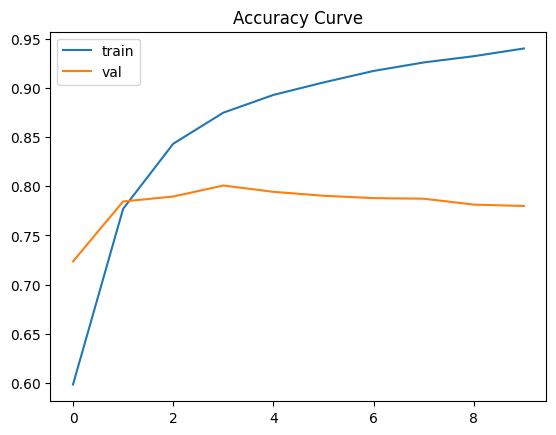

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

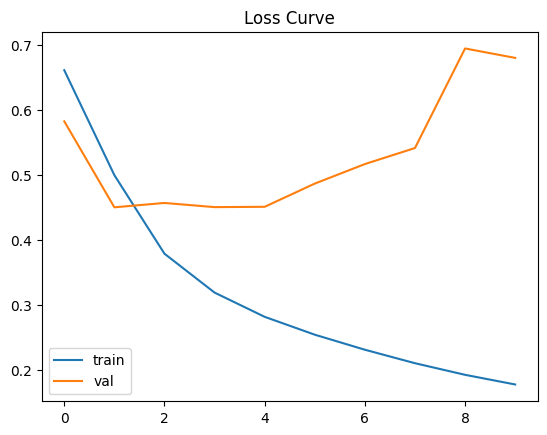

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [ ]:
y_pred=model.predict(X_train)
y_pred = np.where(y_pred > 0.5, 1, 0)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [ ]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precission: ", precision_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))

Accuracy:  0.49592
Recall:  0.48656
Precission:  0.4958421653350726
[[6316 6184]
 [6418 6082]]


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []


In [ ]:
import sys
print(sys.executable)
import platform
print(platform.platform())

c:\Users\maila\AppData\Local\Programs\Python\Python310\python.exe
Windows-10-10.0.26200-SP0


In [ ]:
!nvidia-smi

Wed Aug 26 19:20:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P0              6W /   95W |     583MiB /   6144MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----